# Phase 1: Exploratory Data Analysis
### MAP — Charting Student Math Misunderstandings

This notebook walks through the training data to understand its structure, label distribution, class imbalance, and text characteristics before we build any models. Key findings here will feed directly into the paper.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
from collections import Counter

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

pd.set_option('display.max_colwidth', 120)

## 1. Load the Data

In [2]:
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head(3)

Train shape: (36696, 7)
Test shape:  (3, 5)


,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation,Category,Misconception
0,0,31772,What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equ...,\( \frac{1}{3} \),0ne third is equal to tree nineth,True_Correct,NaN
1,1,31772,What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equ...,\( \frac{1}{3} \),1 / 3 because 6 over 9 is 2 thirds and 1 third is not shaded.,True_Correct,NaN
2,2,31772,What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equ...,\( \frac{1}{3} \),"1 3rd is half of 3 6th, so it is simplee to understand.",True_Neither,NaN


In [3]:
print('Column types:')
print(train.dtypes)
print()
print('Missing values per column:')
print(train.isnull().sum())
print()
print(f'Note: {train["Misconception"].isnull().sum()} rows have no misconception label — these are rows where the student answered correctly or gave a non-classifiable response.')

Column types:
row_id                 int64
QuestionId             int64
QuestionText          object
MC_Answer             object
StudentExplanation    object
Category              object
Misconception         object
dtype: object

Missing values per column:
row_id                    0
QuestionId                0
QuestionText              0
MC_Answer                 0
StudentExplanation        0
Category                  0
Misconception         26836
dtype: int64

Note: 26836 rows have no misconception label — these are rows where the student answered correctly or gave a non-classifiable response.


## 2. Understanding the Label Structure

Each row has two label columns:
- **`Category`** — a compound label combining whether the answer was correct (`True`/`False`) and the quality of the explanation (`Correct`, `Misconception`, `Neither`)
- **`Misconception`** — a specific named misconception, only present when `Category` contains `Misconception`

The prediction target for submission is `Category:Misconception` pairs (top 3 ranked).

In [4]:
print('All unique Category values:')
for cat, count in train['Category'].value_counts().items():
    pct = count / len(train) * 100
    print(f'  {cat:<25} {count:>6} ({pct:.1f}%)')
print()
print('All unique Misconception values (non-null):')
print(sorted(train['Misconception'].dropna().unique().tolist()))

All unique Category values:
  True_Correct               14802 (40.3%)
  False_Misconception         9457 (25.8%)
  False_Neither               6542 (17.8%)
  True_Neither                5265 (14.3%)
  True_Misconception           403 (1.1%)
  False_Correct                227 (0.6%)

All unique Misconception values (non-null):
['Adding_across', 'Adding_terms', 'Additive', 'Base_rate', 'Certainty', 'Definition', 'Denominator-only_change', 'Division', 'Duplication', 'Firstterm', 'FlipChange', 'Ignores_zeroes', 'Incomplete', 'Incorrect_equivalent_fraction_addition', 'Interior', 'Inverse_operation', 'Inversion', 'Irrelevant', 'Longer_is_bigger', 'Mult', 'Multiplying_by_4', 'Not_variable', 'Positive', 'Scale', 'Shorter_is_bigger', 'Subtraction', 'SwapDividend', 'Tacking', 'Unknowable', 'WNB', 'Whole_numbers_larger', 'Wrong_Fraction', 'Wrong_Operation', 'Wrong_fraction', 'Wrong_term']


In [5]:
# Confirm: misconceptions only appear in *_Misconception categories
print('Misconception presence by Category:')
print(train.groupby('Category')['Misconception'].apply(lambda x: f'{x.notna().sum()} labeled / {len(x)} total'))

Misconception presence by Category:
Category
False_Correct              0 labeled / 227 total
False_Misconception    9457 labeled / 9457 total
False_Neither             0 labeled / 6542 total
True_Correct             0 labeled / 14802 total
True_Misconception       403 labeled / 403 total
True_Neither              0 labeled / 5265 total
Name: Misconception, dtype: object


## 3. Category Distribution

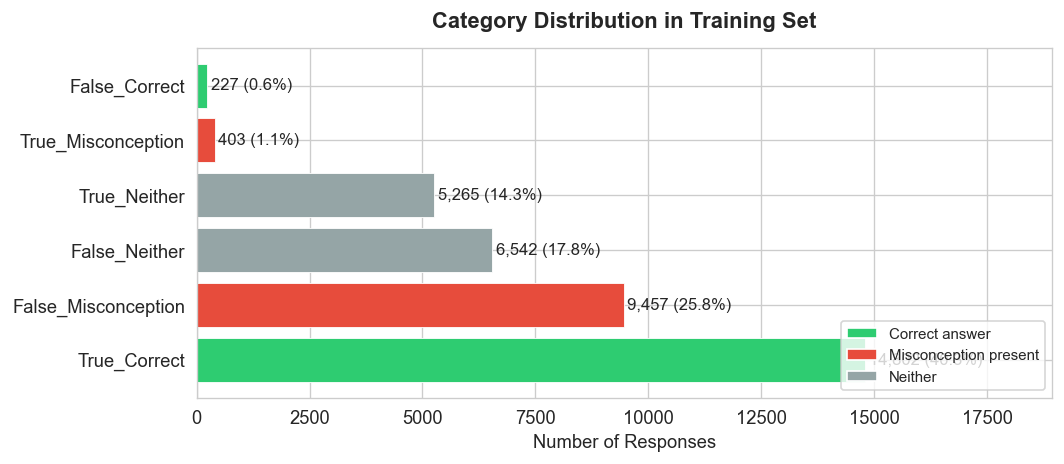

In [6]:
cat_counts = train['Category'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71' if 'Correct' in c else '#e74c3c' if 'Misconception' in c else '#95a5a6' for c in cat_counts.index]
bars = ax.barh(cat_counts.index, cat_counts.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(train)*100:.1f}%)', va='center', fontsize=10)

ax.set_xlabel('Number of Responses')
ax.set_title('Category Distribution in Training Set', fontweight='bold', pad=12)
ax.set_xlim(0, cat_counts.max() * 1.28)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Correct answer'),
                   Patch(facecolor='#e74c3c', label='Misconception present'),
                   Patch(facecolor='#95a5a6', label='Neither')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../notebooks/figures/category_distribution.png', bbox_inches='tight')
plt.show()

## 4. Class Imbalance

The dataset has a significant imbalance. Most responses are either correct (`True_Correct`) or non-classifiable (`*_Neither`). Only the `*_Misconception` categories have a specific misconception label — and those make up a minority of the data.

Total responses:               36696
Responses with misconception:   9860 (26.9%)
Responses without:             26836 (73.1%)


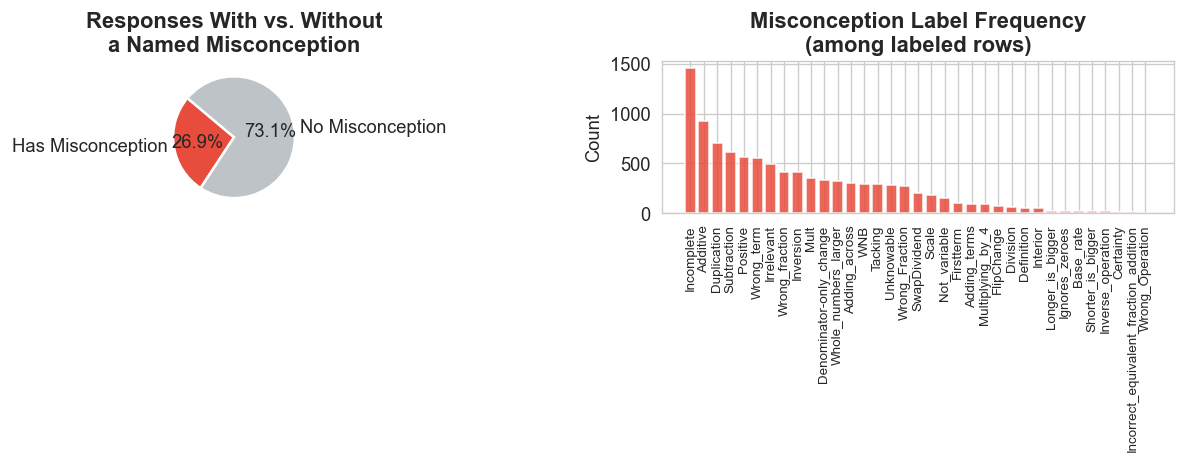

In [7]:
n_total = len(train)
n_misconception = train['Misconception'].notna().sum()
n_no_misconception = train['Misconception'].isna().sum()

print(f'Total responses:              {n_total:>6}')
print(f'Responses with misconception: {n_misconception:>6} ({n_misconception/n_total*100:.1f}%)')
print(f'Responses without:            {n_no_misconception:>6} ({n_no_misconception/n_total*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie: misconception vs no misconception
axes[0].pie([n_misconception, n_no_misconception],
            labels=['Has Misconception', 'No Misconception'],
            autopct='%1.1f%%', colors=['#e74c3c', '#bdc3c7'],
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Responses With vs. Without\na Named Misconception', fontweight='bold')

# Bar: misconception label frequency
misc_counts = train['Misconception'].value_counts()
axes[1].bar(range(len(misc_counts)), misc_counts.values, color='#e74c3c', alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(len(misc_counts)))
axes[1].set_xticklabels(misc_counts.index, rotation=90, fontsize=8)
axes[1].set_ylabel('Count')
axes[1].set_title('Misconception Label Frequency\n(among labeled rows)', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/class_imbalance.png', bbox_inches='tight')
plt.show()

## 5. Data Quality Flag: Case Inconsistency in Misconception Labels

We noticed `Wrong_fraction` and `Wrong_Fraction` appear as separate labels — this is likely a labeling inconsistency in the source data. We need to decide how to handle it before training.

In [8]:
# Check for case-variant duplicates
misc_lower = train['Misconception'].dropna().str.lower()
lower_counts = misc_lower.value_counts()
original_counts = train['Misconception'].dropna().value_counts()

print('Potential case-variant duplicates:')
seen = {}
for val in train['Misconception'].dropna().unique():
    key = val.lower()
    if key in seen:
        print(f'  "{seen[key]}" ({original_counts[seen[key]]}) vs "{val}" ({original_counts[val]})')
    else:
        seen[key] = val

print()
print('Sample Wrong_fraction (lowercase):')  
print(train[train['Misconception']=='Wrong_fraction']['StudentExplanation'].head(2).tolist())
print()
print('Sample Wrong_Fraction (uppercase F):')
print(train[train['Misconception']=='Wrong_Fraction']['StudentExplanation'].head(2).tolist())

Potential case-variant duplicates:
  "Wrong_Fraction" (273) vs "Wrong_fraction" (418)

Sample Wrong_fraction (lowercase):
['24 divided by 8 equals 3 and 3 times 3 equals 9', '3/8 are worth 9. i took it away from 24']

Sample Wrong_Fraction (uppercase F):
['I did 120 divided by 5 then that answer times 2', '1 / 5 equals 24 so 2 of those will be 48.']


## 6. Misconception Distribution (Labeled Rows Only)

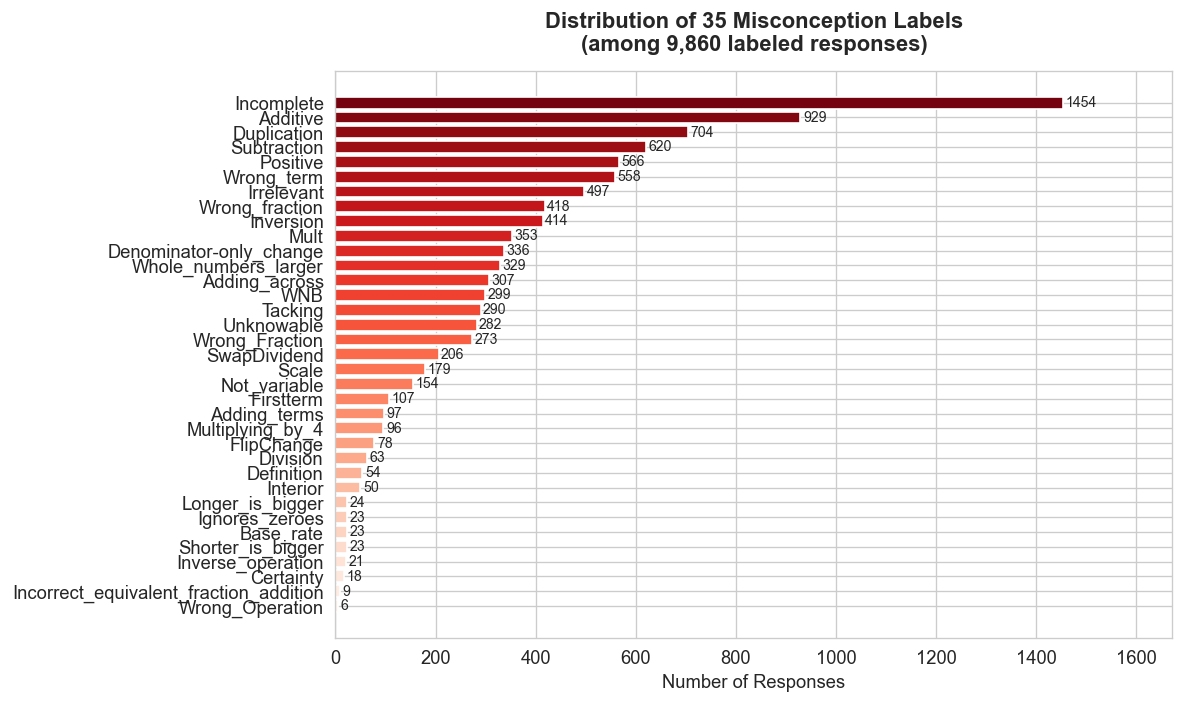


Most common: Incomplete (1454 examples)
Rarest:      Wrong_Operation (6 examples)
Ratio (most/least common): 242.3x


In [9]:
misc_counts = train['Misconception'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('Reds_r', len(misc_counts))
bars = ax.barh(misc_counts.index[::-1], misc_counts.values[::-1], color=palette[::-1], edgecolor='white')

for bar, val in zip(bars, misc_counts.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8.5)

ax.set_xlabel('Number of Responses')
ax.set_title(f'Distribution of {len(misc_counts)} Misconception Labels\n(among {n_misconception:,} labeled responses)', fontweight='bold', pad=12)
ax.set_xlim(0, misc_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('../notebooks/figures/misconception_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nMost common: {misc_counts.index[0]} ({misc_counts.iloc[0]} examples)')
print(f'Rarest:      {misc_counts.index[-1]} ({misc_counts.iloc[-1]} examples)')
print(f'Ratio (most/least common): {misc_counts.iloc[0]/misc_counts.iloc[-1]:.1f}x')

## 7. Combined Prediction Target Distribution

The model actually predicts `Category:Misconception` pairs. Let's look at the full target space.

In [10]:
train['full_label'] = train['Category'] + ':' + train['Misconception'].fillna('NA')
label_counts = train['full_label'].value_counts()

print(f'Total unique prediction targets: {len(label_counts)}')
print()
print('Top 15 most common targets:')
print(label_counts.head(15).to_string())
print()
print('Bottom 10 rarest targets:')
print(label_counts.tail(10).to_string())

Total unique prediction targets: 65

Top 15 most common targets:
full_label
True_Correct:NA                                14802
False_Neither:NA                                6542
True_Neither:NA                                 5265
False_Misconception:Incomplete                  1446
False_Misconception:Additive                     891
False_Misconception:Duplication                  698
False_Misconception:Subtraction                  618
False_Misconception:Positive                     564
False_Misconception:Wrong_term                   550
False_Misconception:Wrong_fraction               412
False_Misconception:Irrelevant                   409
False_Misconception:Inversion                    409
False_Misconception:Mult                         345
False_Misconception:Denominator-only_change      332
False_Misconception:Whole_numbers_larger         328

Bottom 10 rarest targets:
full_label
True_Misconception:Definition                                3
True_Misconception:Multiplyi

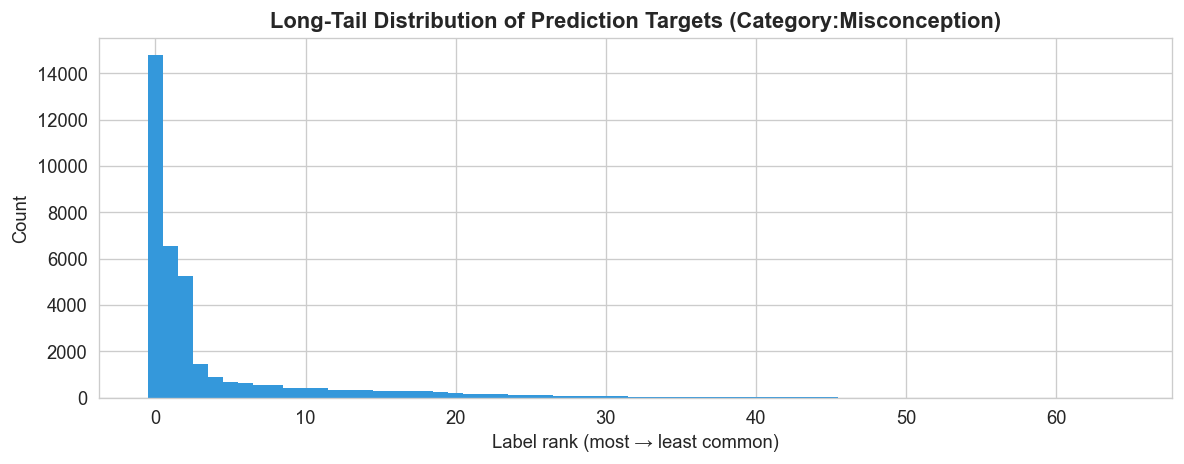

In [11]:
# Show the long-tail nature of the label distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(label_counts)), label_counts.values, color='#3498db', width=1.0, edgecolor='none')
ax.set_xlabel('Label rank (most → least common)')
ax.set_ylabel('Count')
ax.set_title('Long-Tail Distribution of Prediction Targets (Category:Misconception)', fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/figures/label_longtail.png', bbox_inches='tight')
plt.show()

## 8. Student Explanation Length

In [12]:
train['explanation_words'] = train['StudentExplanation'].str.split().str.len()
train['explanation_chars'] = train['StudentExplanation'].str.len()

print('Word count statistics:')
print(train['explanation_words'].describe().round(1))
print()

# Does explanation length differ by category?
print('Median word count by Category:')
print(train.groupby('Category')['explanation_words'].median().sort_values(ascending=False).round(1))

Word count statistics:
count    36696.0
mean        15.4
std          8.1
min          1.0
25%         10.0
50%         13.0
75%         19.0
max        177.0
Name: explanation_words, dtype: float64

Median word count by Category:
Category
False_Correct          17.0
True_Correct           16.0
True_Misconception     15.0
False_Misconception    13.0
False_Neither          11.0
True_Neither           11.0
Name: explanation_words, dtype: float64


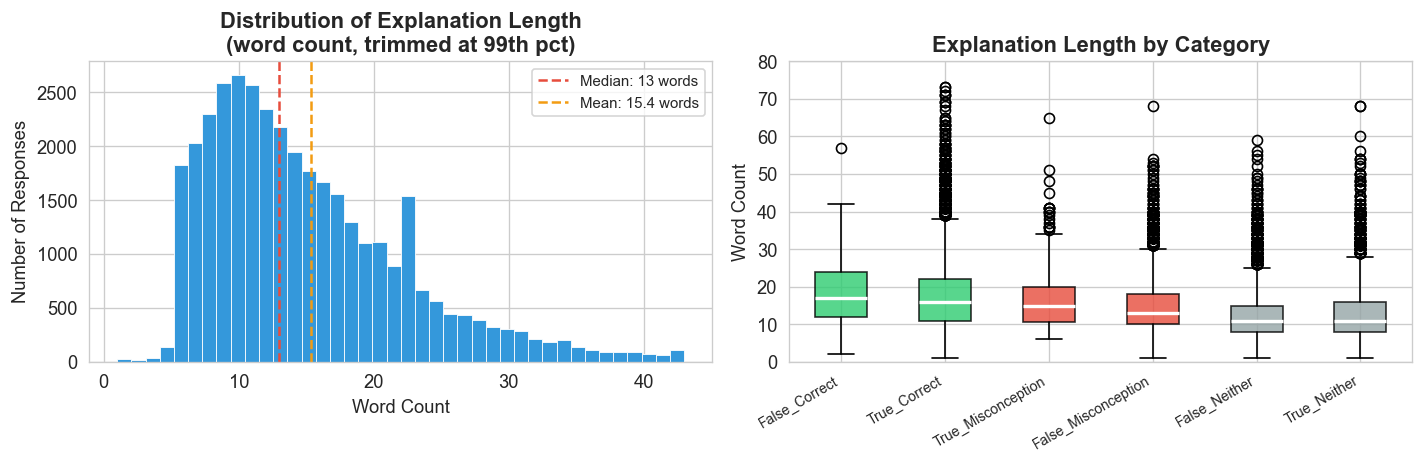

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of word counts (trimmed at 99th percentile for readability)
p99 = train['explanation_words'].quantile(0.99)
trimmed = train[train['explanation_words'] <= p99]['explanation_words']
axes[0].hist(trimmed, bins=40, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0].axvline(train['explanation_words'].median(), color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'Median: {train["explanation_words"].median():.0f} words')
axes[0].axvline(train['explanation_words'].mean(), color='#f39c12', linestyle='--', linewidth=1.5,
                label=f'Mean: {train["explanation_words"].mean():.1f} words')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Number of Responses')
axes[0].set_title('Distribution of Explanation Length\n(word count, trimmed at 99th pct)', fontweight='bold')
axes[0].legend(fontsize=9)

# Box plot by category
cat_order = train.groupby('Category')['explanation_words'].median().sort_values(ascending=False).index
cat_data = [train[train['Category'] == cat]['explanation_words'].values for cat in cat_order]
bp = axes[1].boxplot(cat_data, patch_artist=True, vert=True,
                     medianprops={'color': 'white', 'linewidth': 2})
colors_box = ['#2ecc71' if 'Correct' in c else '#e74c3c' if 'Misconception' in c else '#95a5a6' for c in cat_order]
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_xticklabels(cat_order, rotation=30, ha='right', fontsize=8.5)
axes[1].set_ylabel('Word Count')
axes[1].set_ylim(0, 80)
axes[1].set_title('Explanation Length by Category', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/explanation_length.png', bbox_inches='tight')
plt.show()

## 9. Question Distribution

There are only 15 unique questions in the dataset — every student response is tied to one of these. Understanding which questions generate the most misconceptions is useful context.

In [14]:
q_summary = train.groupby('QuestionId').agg(
    total_responses=('row_id', 'count'),
    with_misconception=('Misconception', lambda x: x.notna().sum()),
    unique_misconceptions=('Misconception', 'nunique'),
    question_text=('QuestionText', 'first')
).reset_index()

q_summary['misconception_rate'] = (q_summary['with_misconception'] / q_summary['total_responses'] * 100).round(1)

# Short label for each question
def shorten(text, n=55):
    text = re.sub(r'\\\(.*?\\\)', '[math]', text)
    return text[:n] + '...' if len(text) > n else text

q_summary['short_text'] = q_summary['question_text'].apply(shorten)

print(q_summary[['QuestionId','total_responses','with_misconception','misconception_rate','unique_misconceptions','short_text']]
      .sort_values('with_misconception', ascending=False)
      .to_string(index=False))

 QuestionId  total_responses  with_misconception  misconception_rate  unique_misconceptions                                                   short_text
      31772             4857                1621                33.4                      2   What fraction of the shape is not shaded? Give your ans...
      31778             3640                1422                39.1                      3                         [math] What is the value of [math] ?
      32833             3105                1124                36.2                      3                                             Calculate [math]
      89443             3054                 856                28.0                      2   What number belongs in the box?\n\(\n(-8)-(-5)=\n\square\)
      33474             1766                 683                38.7                      2   Sally has [math] of a whole cake in the fridge. Robert ...
      91695             2610                 665                25.5              

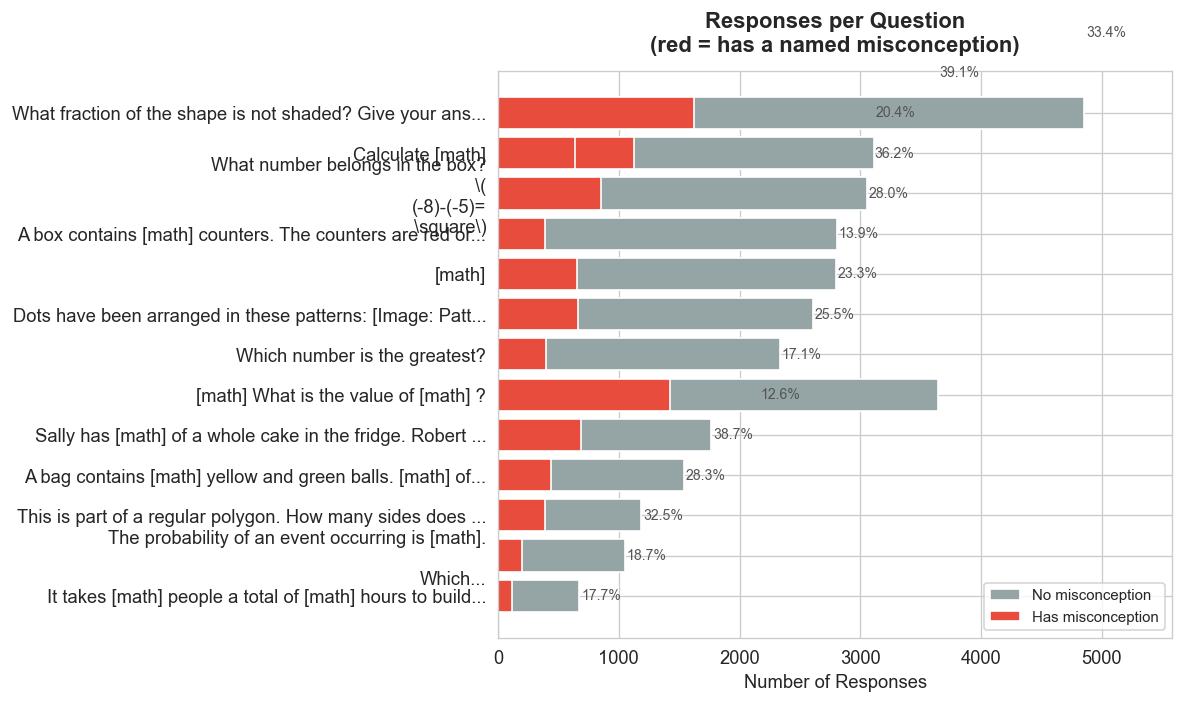

In [15]:
q_plot = q_summary.sort_values('total_responses', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(q_plot['short_text'], q_plot['total_responses'], color='#95a5a6', label='No misconception', edgecolor='white')
ax.barh(q_plot['short_text'], q_plot['with_misconception'], color='#e74c3c', label='Has misconception', edgecolor='white')

for i, (total, misc, rate) in enumerate(zip(q_plot['total_responses'], q_plot['with_misconception'], q_plot['misconception_rate'])):
    ax.text(total + 15, i, f'{rate}%', va='center', fontsize=8.5, color='#555')

ax.set_xlabel('Number of Responses')
ax.set_title('Responses per Question\n(red = has a named misconception)', fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.set_xlim(0, q_plot['total_responses'].max() * 1.15)
plt.tight_layout()
plt.savefig('../notebooks/figures/question_distribution.png', bbox_inches='tight')
plt.show()

## 10. Text Cleaning & Preprocessing

Before training we need to clean the text. The main issues are:
1. **LaTeX notation** in question text: `\( \frac{1}{2} \)` — needs to be stripped or converted
2. **Image references**: `[Image: ...]` — can't use visual content, so we strip these
3. **Case normalization**: student explanations are lowercase in practice but inconsistent
4. **Misconception label case inconsistency**: `Wrong_fraction` vs `Wrong_Fraction`

In [16]:
def clean_question_text(text):
    """Remove LaTeX delimiters and image placeholders from question text."""
    # Remove \( and \) LaTeX inline delimiters, keep the content
    text = re.sub(r'\\\(\s*', '', text)
    text = re.sub(r'\s*\\\)', '', text)
    # Remove display math \[ \]
    text = re.sub(r'\\\[\s*', '', text)
    text = re.sub(r'\s*\\\]', '', text)
    # Replace [Image: ...] blocks with a placeholder token
    text = re.sub(r'\[Image:[^\]]*\]', '[image]', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_explanation(text):
    """Lowercase and normalize whitespace for student explanations."""
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def fix_misconception_case(text):
    """Unify case variants of the same misconception label."""
    if pd.isna(text):
        return text
    # Normalize Wrong_fraction / Wrong_Fraction -> Wrong_Fraction
    return text.replace('Wrong_fraction', 'Wrong_Fraction')

# Apply cleaning
train['QuestionText_clean']      = train['QuestionText'].apply(clean_question_text)
train['StudentExplanation_clean'] = train['StudentExplanation'].apply(clean_explanation)
train['Misconception_clean']     = train['Misconception'].apply(fix_misconception_case)

# Verify
print('Before cleaning:')
print(' ', train.loc[1, 'QuestionText'])
print()
print('After cleaning:')
print(' ', train.loc[1, 'QuestionText_clean'])
print()
print('Misconception label fix:')
print(f'  Wrong_fraction count before: {(train["Misconception"]=="Wrong_fraction").sum()}')
print(f'  Wrong_fraction count after:  {(train["Misconception_clean"]=="Wrong_fraction").sum()}')
print(f'  Wrong_Fraction count before: {(train["Misconception"]=="Wrong_Fraction").sum()}')
print(f'  Wrong_Fraction count after:  {(train["Misconception_clean"]=="Wrong_Fraction").sum()}')

Before cleaning:
  What fraction of the shape is not shaded? Give your answer in its simplest form. [Image: A triangle split into 9 equal smaller triangles. 6 of them are shaded.]

After cleaning:
  What fraction of the shape is not shaded? Give your answer in its simplest form. [image]

Misconception label fix:
  Wrong_fraction count before: 418
  Wrong_fraction count after:  0
  Wrong_Fraction count before: 273
  Wrong_Fraction count after:  691


In [17]:
# Build a combined input field (what the model will actually see)
# Format: "Question: {question} Answer: {mc_answer} Explanation: {explanation}"
train['model_input'] = (
    'Question: ' + train['QuestionText_clean'] + ' ' +
    'Answer: ' + train['MC_Answer'] + ' ' +
    'Explanation: ' + train['StudentExplanation_clean']
)

print('Sample model input:')
print(train.loc[107, 'model_input'])
print()
print('Label:', train.loc[107, 'full_label'])

# Token length estimate (rough: 1 word ≈ 1.3 tokens)
train['input_words'] = train['model_input'].str.split().str.len()
print(f'\nModel input word count stats:')
print(train['input_words'].describe().round(1))
print(f'\n~99% of inputs are under {train["input_words"].quantile(0.99):.0f} words — well within BERT\'s 512 token limit.')

Sample model input:
Question: What fraction of the shape is not shaded? Give your answer in its simplest form. [image] Answer: \( \frac{1}{3} \) Explanation: 3 out of 9 parts aren't shaded.

Label: True_Misconception:Incomplete

Model input word count stats:
count    36696.0
mean        33.7
std         11.7
min         10.0
25%         25.0
50%         32.0
75%         40.0
max        191.0
Name: input_words, dtype: float64

~99% of inputs are under 66 words — well within BERT's 512 token limit.


## 11. Save Cleaned Dataset

In [18]:
# Save cleaned train data
cols_to_save = ['row_id', 'QuestionId', 'QuestionText_clean', 'MC_Answer',
                'StudentExplanation_clean', 'Category', 'Misconception_clean',
                'full_label', 'model_input']
train[cols_to_save].to_csv('../data/train_clean.csv', index=False)

# Apply same cleaning to test
test['QuestionText_clean']       = test['QuestionText'].apply(clean_question_text)
test['StudentExplanation_clean'] = test['StudentExplanation'].apply(clean_explanation)
test['model_input'] = (
    'Question: ' + test['QuestionText_clean'] + ' ' +
    'Answer: ' + test['MC_Answer'] + ' ' +
    'Explanation: ' + test['StudentExplanation_clean']
)
test.to_csv('../data/test_clean.csv', index=False)

print('Saved: data/train_clean.csv')
print('Saved: data/test_clean.csv')
print(f'Unique labels (Category:Misconception) in training set: {train["full_label"].nunique()}')

Saved: data/train_clean.csv
Saved: data/test_clean.csv
Unique labels (Category:Misconception) in training set: 65


## 12. Summary of Key Findings

Here's a summary of what we learned from the data — these points will feed directly into the paper's Dataset section:

| Finding | Detail |
|---|---|
| Dataset size | 36,696 training rows, 15 unique questions |
| Label structure | 6 Category values × up to 35 Misconceptions |
| Class imbalance | Only ~27% of responses have a named misconception |
| Misconception count | 35 unique labels (after fixing `Wrong_fraction` case inconsistency → 34) |
| Most common misconception | `Incomplete` (1,454 examples) |
| Rarest misconception | Several labels with <30 examples — long tail problem |
| Explanation length | Median 13 words, mean 15.4 words — very short texts |
| Input length | Combined input (question + answer + explanation) fits well within BERT's 512 token limit |
| LaTeX notation | Questions use LaTeX math notation (`\\( \\frac{1}{2} \\)`) — stripped in preprocessing |
| Image references | Some questions reference diagrams — converted to `[image]` placeholder |
